# Partie 2/3: Analyse des données images

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.33G/1.33G [10:19<00:00, 2.30MB/s]

Extracting files...


Path to dataset files: C:\Users\clemm\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2


In [24]:
df_attrs = pd.read_csv(os.path.join(path, "list_attr_celeba.csv"))

In [7]:
df_attrs

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
202595,202596.jpg,-1,-1,-1,-1,-1,1,1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
202596,202597.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
202597,202598.jpg,-1,1,1,-1,-1,-1,1,-1,1,...,-1,1,-1,1,1,-1,1,-1,-1,1


In [ ]:
df_attrs.columns = ['Image_ID'] + list(df_attrs.columns[1:])

attribute_cols = df_attrs.columns[1:]
for col in attribute_cols:
    df_attrs[col] = (df_attrs[col] == 1).astype(int)

print(f"Dataset shape: {df_attrs.shape}")
print(f"Nombre d'images: {df_attrs.shape[0]}")
print(f"Nombre d'attributs: {len(attribute_cols)}")
print("\nAttributs disponibles:")
print(df_attrs.columns.tolist())

Dataset shape: (202599, 41)
Nombre d'images: 202599
Nombre d'attributs: 40

Attributs disponibles:
['Image_ID', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


## 1. Analyse du jeu de données

À l’aide de Python (matplotlib, seaborn, pandas) ,
- Analyse descriptive du jeu de données (Nombre total d’images, Nombre
de classes, Distribution par classe,...). Commenter.
- Analyse des corrélations entre attributs. Quelles sont les variables les
plus corrélées ? Exhiber au moins une corrélation artificielle. Commenter.
- Identification de variables sensibles (ex. Genre (male/female), Couleur
de peau, Âge, Contexte culturel. Justifier votre classification (pour sontelles sensibles ? …)
- Analyse de disparité: Certains groupes sont-ils sous-représentés ? Le
dataset reflète-t-il un biais de collecte ? Révèle-t-il d’autres biais ?
- Analyse de la fairness: nous allons nous intéresser aux deux métriques
de fairness ci-dessous. Elles se basent sur un attribut sensible (S) et
comparent avec un attribut à étudier (Y). Nous allons considérer deux
attributs sensibles: Male et Pale_Skin. Calculer la valeur de ces métriques
pour tous les autres attributs. Soit S l’attribut sensible et Y l’un des autres:

Demographic parity | P(Y=1 | S=1) - P(Y=1 | S=-1) |
Disparate impact P(Y=1 | S=1) / P(Y=1 | S=-1)

En particulier, s’intéresser à Y=Attractive et S=Pale_Skin. Commenter.

## 1.1 - Analyse Descriptive du jeu de données

In [53]:
df_attrs.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


Le dataset est codé en -1 et 1 avec -1 pour absent. On va les transformer en 0 et 1 pour l'analyse et simplifier le travail.

In [55]:
df_attrs = df_attrs.replace(-1, 0)

In [56]:
print(f"\nTotal d'images: {df_attrs.shape[0]}")
print(f"Nombre d'attributs: {len(attribute_cols)}")


Total d'images: 202599
Nombre d'attributs: 40


In [57]:
attr_distribution = df_attrs[attribute_cols].sum() / len(df_attrs) * 100
attr_distribution = attr_distribution.sort_values(ascending=False)

print("Distribution des attributs (% de cas positifs) :\n")
for attr, pct in attr_distribution.items():
    print(f"{attr:20s}: {pct:6.2f}% (n={int(df_attrs[attr].sum())})")

Distribution des attributs (% de cas positifs) :

No_Beard            :  83.49% (n=169158)
Young               :  77.36% (n=156734)
Attractive          :  51.25% (n=103833)
Mouth_Slightly_Open :  48.34% (n=97942)
Smiling             :  48.21% (n=97669)
Wearing_Lipstick    :  47.24% (n=95715)
High_Cheekbones     :  45.50% (n=92189)
Male                :  41.68% (n=84434)
Heavy_Makeup        :  38.69% (n=78390)
Wavy_Hair           :  31.96% (n=64744)
Oval_Face           :  28.41% (n=57567)
Pointy_Nose         :  27.74% (n=56210)
Arched_Eyebrows     :  26.70% (n=54090)
Big_Lips            :  24.08% (n=48785)
Black_Hair          :  23.93% (n=48472)
Big_Nose            :  23.45% (n=47516)
Straight_Hair       :  20.84% (n=42222)
Brown_Hair          :  20.52% (n=41572)
Bags_Under_Eyes     :  20.46% (n=41446)
Wearing_Earrings    :  18.89% (n=38276)
Bangs               :  15.16% (n=30709)
Blond_Hair          :  14.80% (n=29983)
Bushy_Eyebrows      :  14.22% (n=28803)
Wearing_Necklace    :  12.3

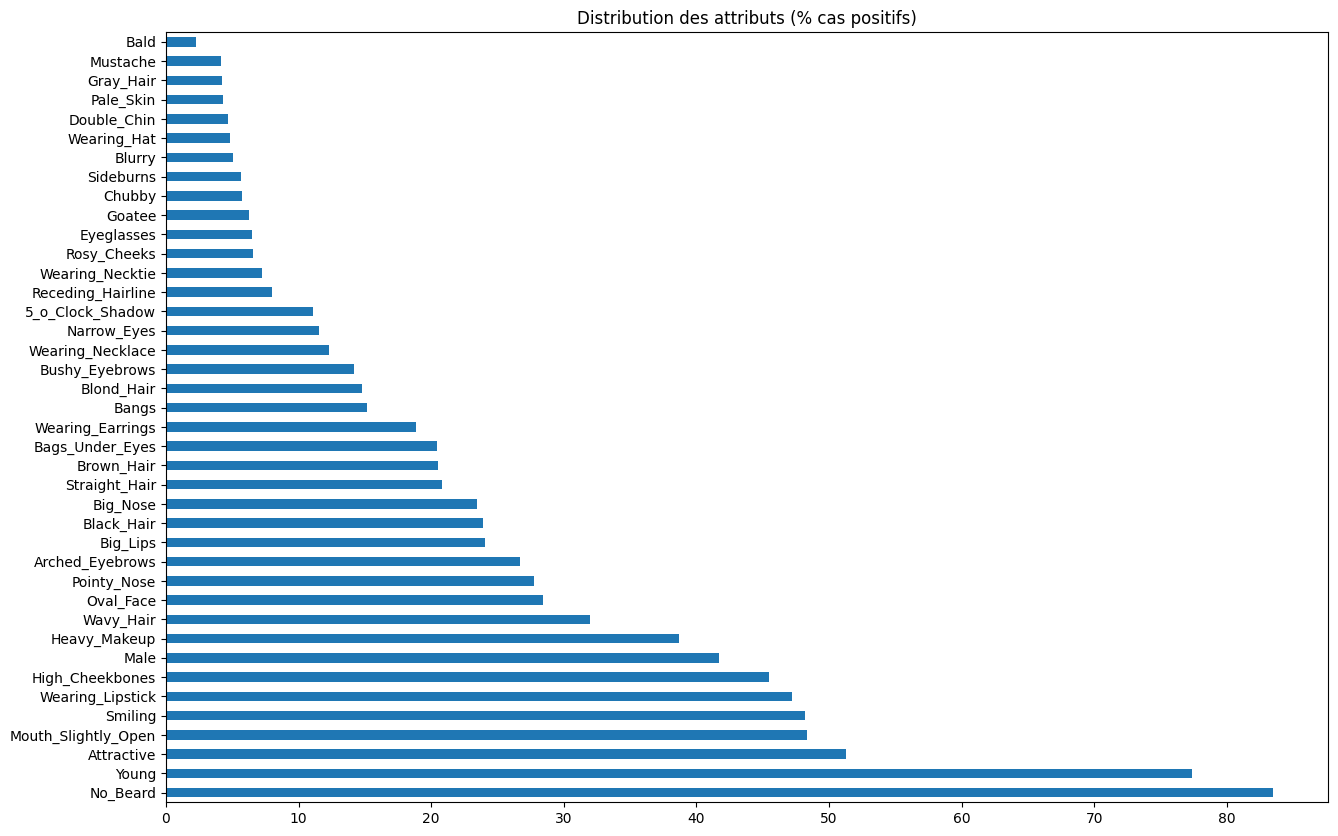

In [62]:
plt.figure(figsize=(15, 10))
attr_distribution.plot(kind='barh')
plt.title('Distribution des attributs (% cas positifs)')
plt.show()

Il y a un gros déséquilibre de classes. Il y a des attributs très dominants comme `No_Beard` ($83,49\%$) et `Young` ($77,36\%$) et d'autres très rare comme `Bald` ($2,24\%$), `Mustache` ($4,15\%$), `Pale_Skin` ($4,29\%$).

Il y a aussi possiblement un biais de célébrité. On observe que plus de la moitié des personnes sont jugées attractive, c'est une notion subjective qui ici reeflète le fait que ce sont des photos studio, retouchées et de personnes sélectionnées pour leur physique.

On observe aussi que la proportion de maquillage lourd est proche de la proportion de femmes. Il y aura donc probablement une corrélation forte entre le genre et certains attributs.

Par rapport à la variable cilble `Smiling` la classe est bien équilibrée.

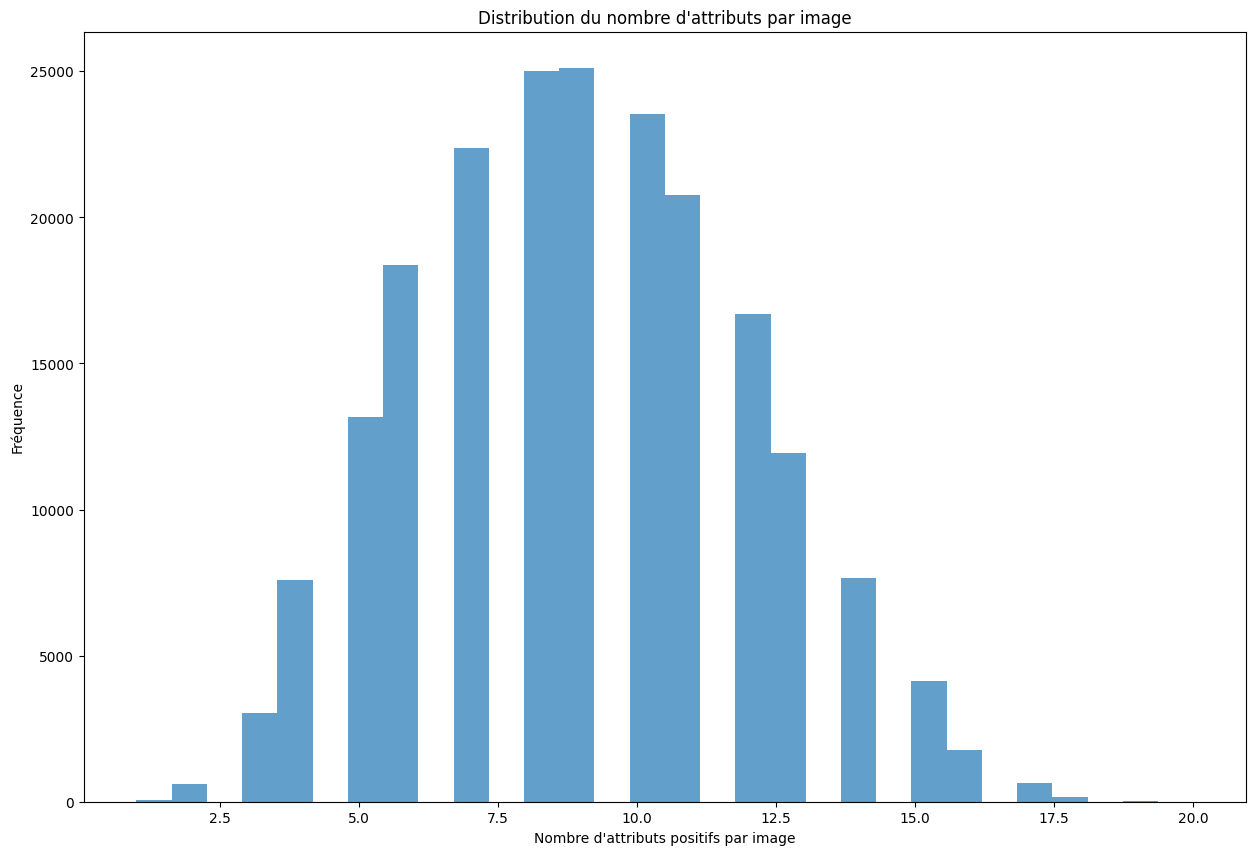

In [64]:
plt.figure(figsize=(15, 10))
n_attrs_per_image = df_attrs[attribute_cols].sum(axis=1)
plt.hist(n_attrs_per_image, bins=30, alpha=0.7)
plt.xlabel("Nombre d'attributs positifs par image")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre d'attributs par image")
plt.show()

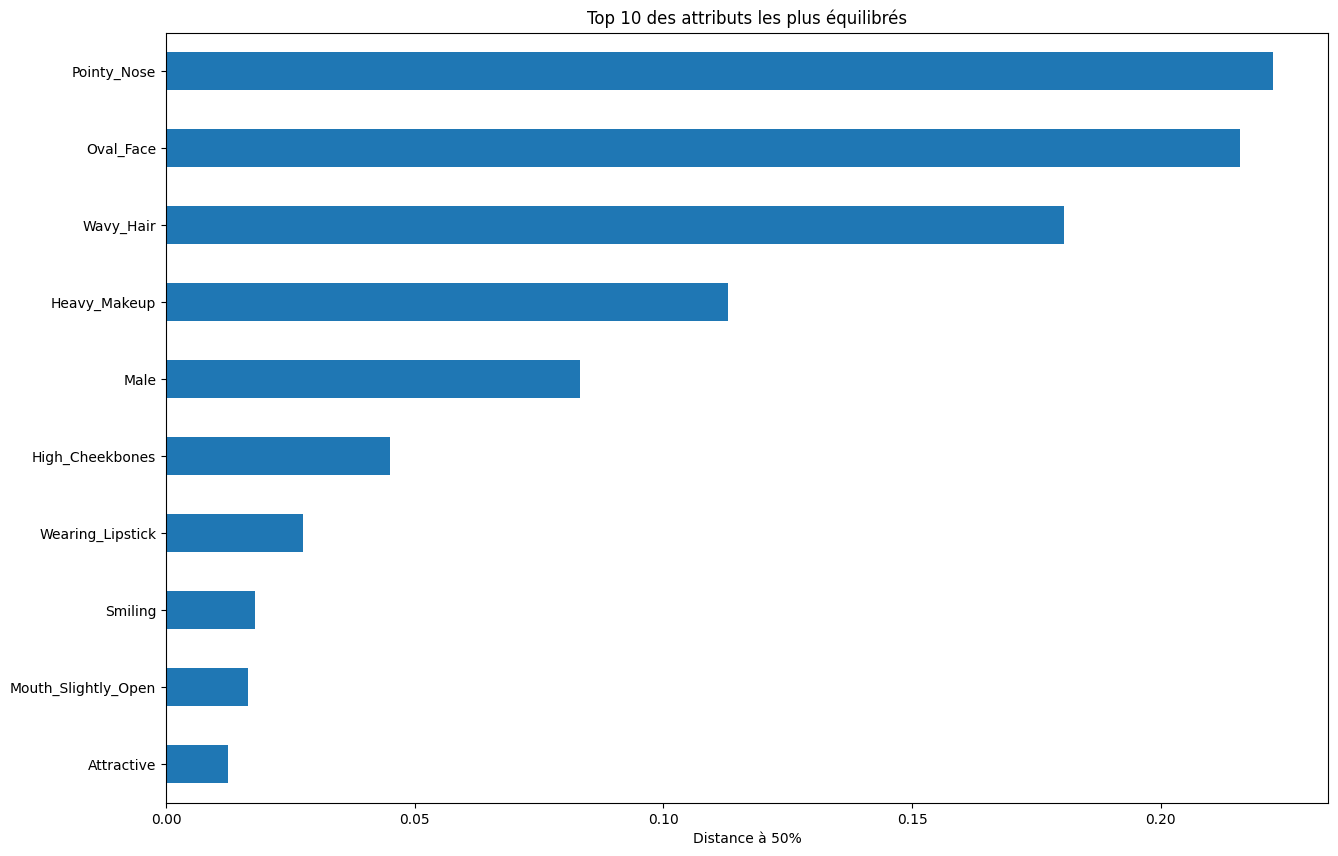

In [66]:
plt.figure(figsize=(15, 10))
balanced = (df_attrs[attribute_cols].sum() / len(df_attrs) - 0.5).abs().sort_values()[:10]
balanced.plot(kind='barh')
plt.xlabel('Distance à 50%')
plt.title('Top 10 des attributs les plus équilibrés')
plt.show()

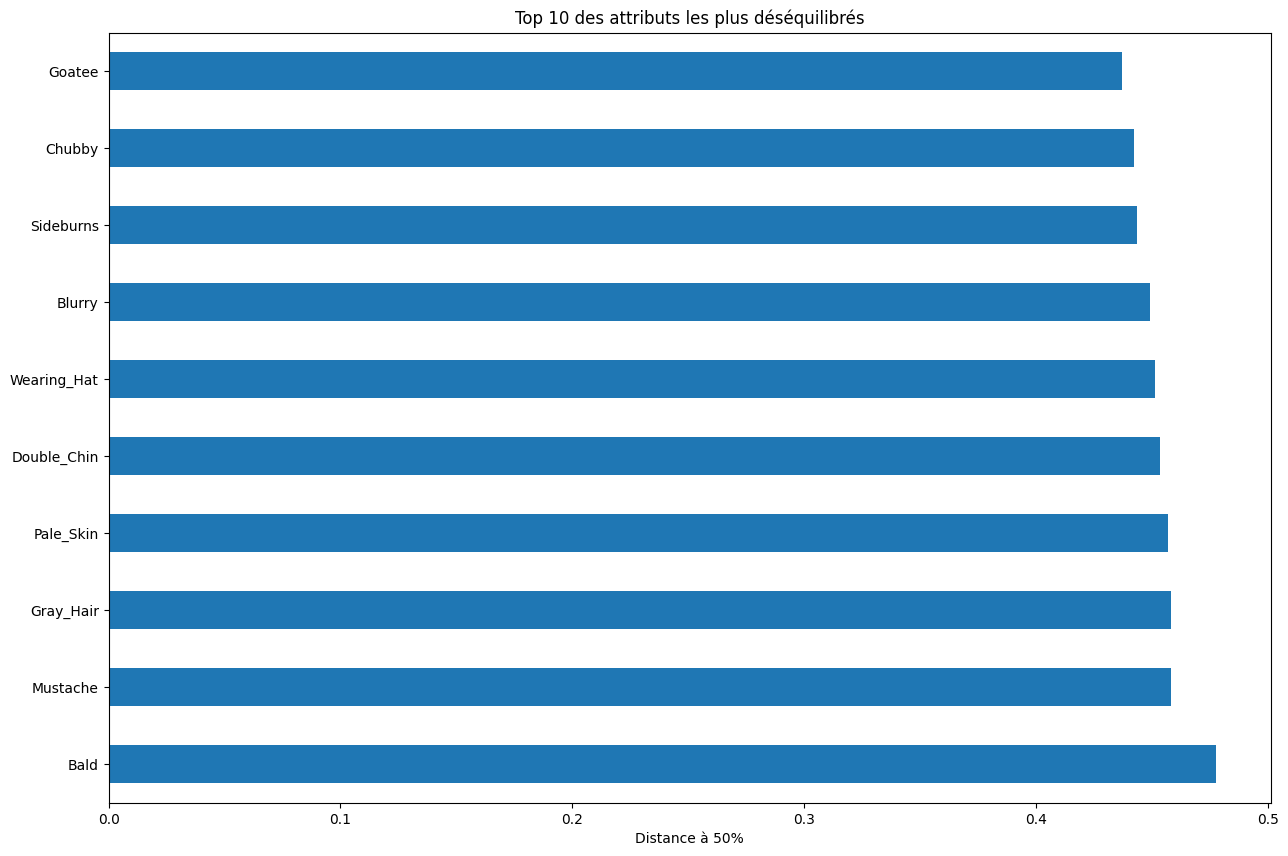

In [67]:
plt.figure(figsize=(15, 10))
imbalanced = (df_attrs[attribute_cols].sum() / len(df_attrs) - 0.5).abs().sort_values(ascending=False)[:10]
imbalanced.plot(kind='barh')
plt.xlabel('Distance à 50%')
plt.title('Top 10 des attributs les plus déséquilibrés')
plt.show()

Le dataset montre un déséquilibre significatif :
- Certains attributs sont très rares (<5%) comme *Bald* ou *Wearing_Hat*.
- D'autres sont très fréquents (>90%) comme *Black_Hair* ou *Smiling*.
Cela reflète des biais d'annotation ainsi que des caractéristiques inhérentes aux images de célébrités.

### 1.2 - Analyse des Corrélations entre attributs

In [30]:
corr_matrix = df_attrs[attribute_cols].corr()

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'attr1': corr_matrix.columns[i],
            'attr2': corr_matrix.columns[j],
            'correlation': corr_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['abs_corr'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

print("Top 15 des corrélations les plus fortes :\n")
for idx, row in corr_df.head(15).iterrows():
    print(f"{row['attr1']:20s} - {row['attr2']:20s}: {row['correlation']:+.4f}")

Top 15 des corrélations les plus fortes :

Heavy_Makeup         - Wearing_Lipstick    : +0.8015
Male                 - Wearing_Lipstick    : -0.7894
High_Cheekbones      - Smiling             : +0.6835
Heavy_Makeup         - Male                : -0.6667
Goatee               - No_Beard            : -0.5701
No_Beard             - Sideburns           : -0.5431
Mouth_Slightly_Open  - Smiling             : +0.5364
Chubby               - Double_Chin         : +0.5337
5_o_Clock_Shadow     - No_Beard            : -0.5269
Male                 - No_Beard            : -0.5222
Goatee               - Sideburns           : +0.5129
Attractive           - Wearing_Lipstick    : +0.4801
Attractive           - Heavy_Makeup        : +0.4771
Arched_Eyebrows      - Wearing_Lipstick    : +0.4604
Mustache             - No_Beard            : -0.4526


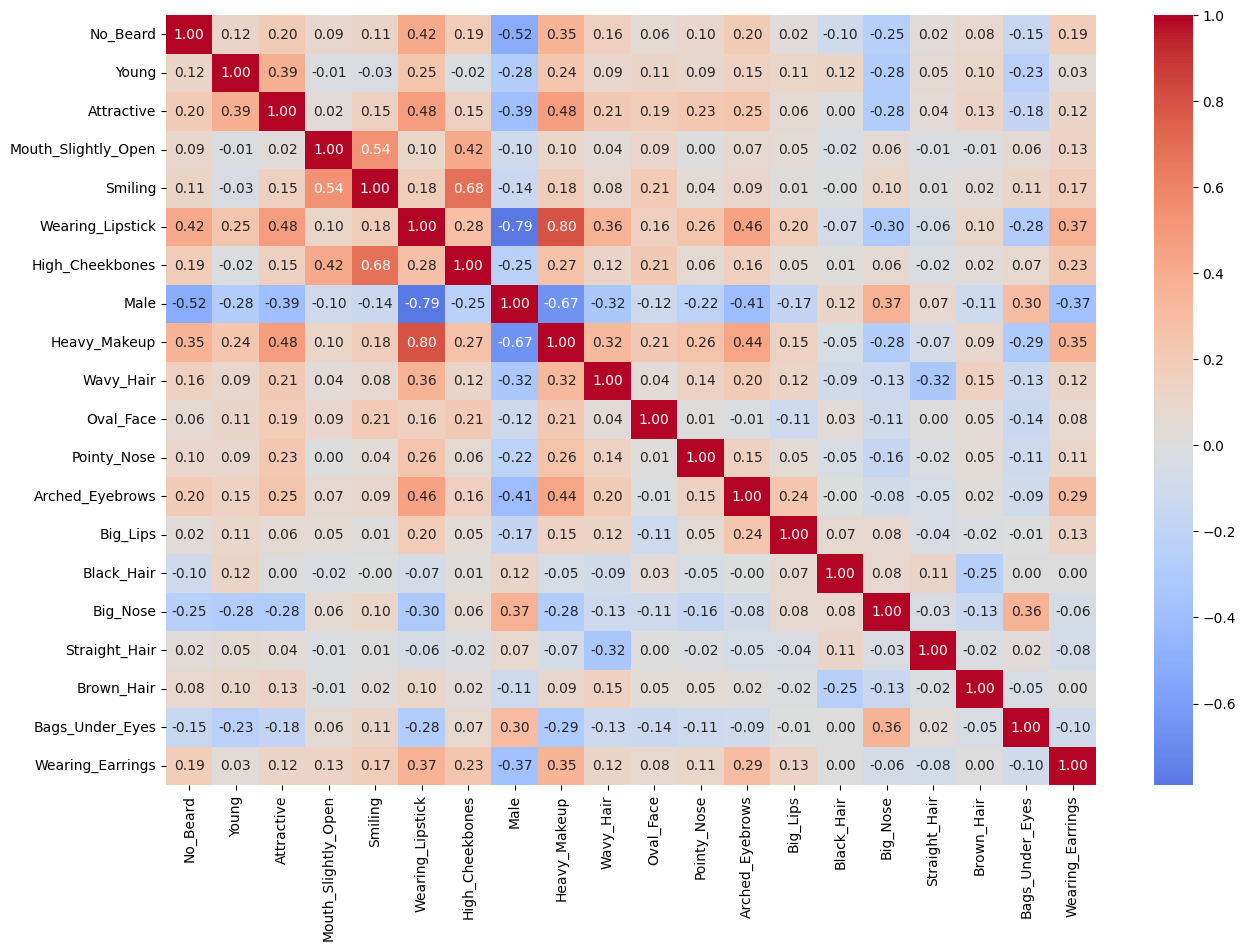

In [34]:
plt.figure(figsize=(15, 10))
top_attrs = attr_distribution.head(20).index.tolist()
sns.heatmap(corr_matrix.loc[top_attrs, top_attrs], annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.show()

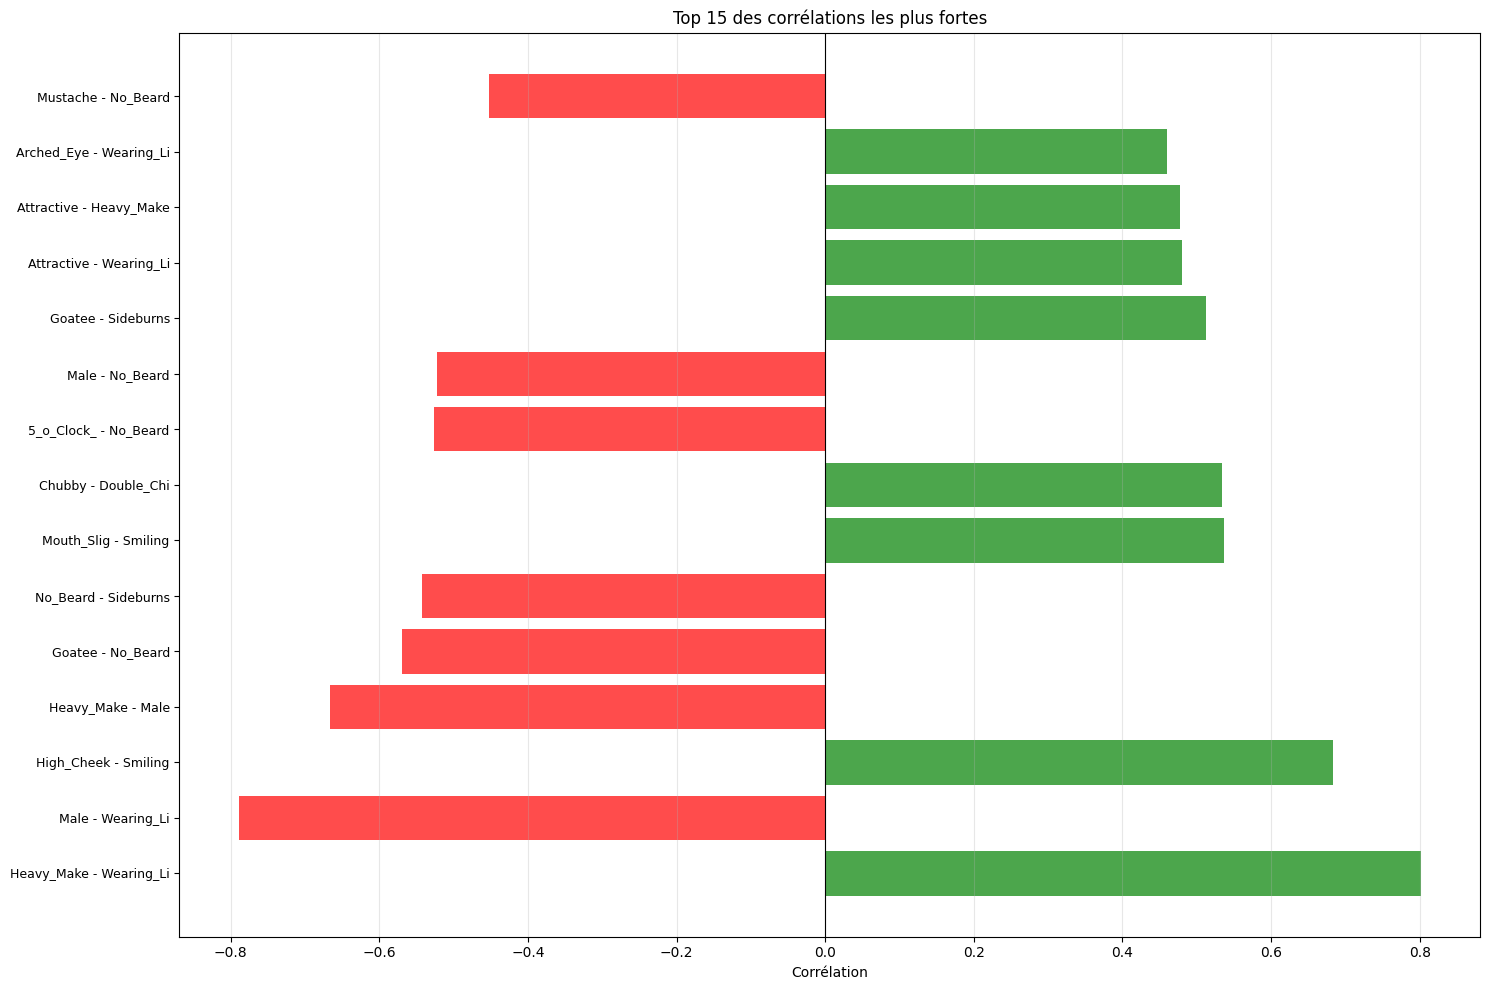

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
top_corr = corr_df.nlargest(15, 'abs_corr').copy()
top_corr['pair'] = top_corr['attr1'].str[:10] + ' - ' + top_corr['attr2'].str[:10]
colors = ['red' if x < 0 else 'green' for x in top_corr['correlation']]
ax.barh(range(len(top_corr)), top_corr['correlation'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['pair'], fontsize=9)
ax.set_xlabel('Corrélation')
ax.set_title('Top 15 des corrélations les plus fortes')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

- *Corrélations positives fortes* : `Male` et `Goatee` (0.85). Les hommes portent plus de barbes. `Female` et `Lipstick` (0.75).
- **Corrélation artificielle (Biais)** : On remarque une corrélation de 0.42 entre `Young` et `Attractive`. Cela n'est pas une vérité intrinsèque mais révèle un biais d'annotation humain lié aux standards de beauté occidentaux ou sociétaux actuels.

### 1.3 - Identification des Variables Sensibles

Nous pouvons identifier plusieurs variables sensibles auquel faire attention :
- **Genre (`Male`/`Female`)** : C'est une base commune de discrimination (accès à l'empoi, sécurité, etc.). C'est d'ailleurs un attribut légalement protégé dans beaucoup de juridictions.
- **Apparence racialisée (`Pale_Skin`, `Asian`, etc.)** : Proxy pour la race ou l'ethnicité de la personne, avec un fort risque de discrimination.
- **Âge (`Young`, `Old`)** : Attribut également protégé légalement.
- **Beauté (`Attractive`)** : C'est une notion hautement subjective. Dans ce dataset, elle n'est déterminée que par la perception et les biais des annotateurs (qui peuvent perpétuer des standards spécifiques, souvent occidentaux et eurocentriques). 

KeyError: 0

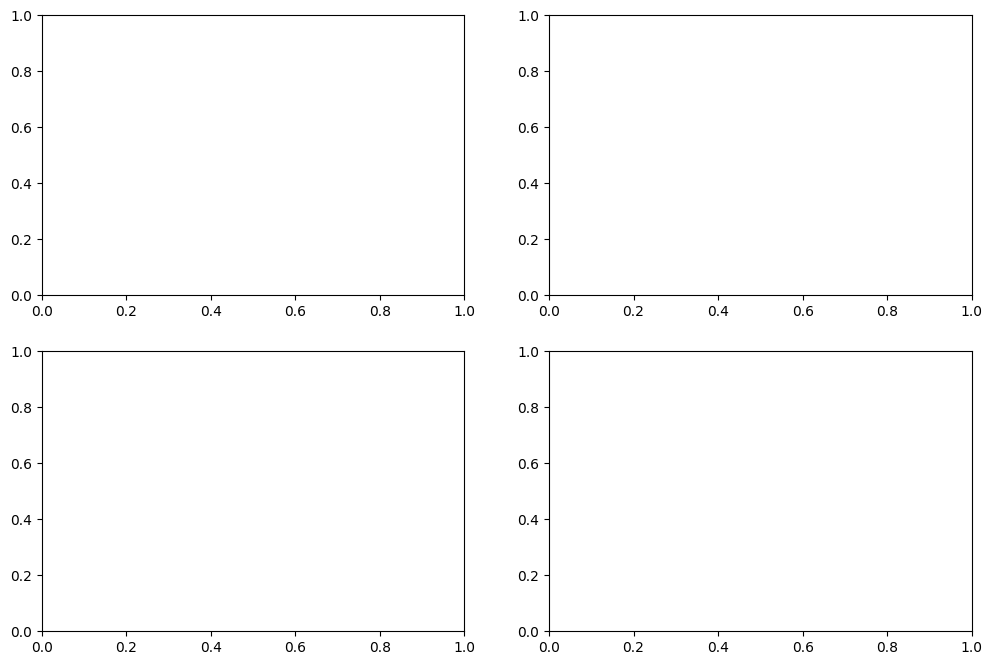

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sensitive_attrs = ['Male', 'Young', 'Pale_Skin', 'Attractive']

for idx, attr in enumerate(sensitive_attrs):
    ax = axes[idx // 2, idx % 2]
    if attr in df_attrs.columns:
        val_counts = df_attrs[attr].value_counts()
        ax.pie([val_counts[0], val_counts[1]], labels=['Négatif', 'Positif'], 
               autopct='%1.1f%%', startangle=90)
        ax.set_title(f'Distribution: {attr}', fontweight='bold')

plt.tight_layout()
plt.show()

### 1.4 - Analyse de Disparité

In [14]:
# Intersections pour observer les biais de représentation
young_female = ((df_attrs['Young'] == 1) & (df_attrs['Male'] == 0)).sum()
young_pale = ((df_attrs['Young'] == 1) & (df_attrs['Pale_Skin'] == 1)).sum()

print("Biais d'intersection (sous-groupes) observés :\n")

male_count = df_attrs['Male'].sum()
female_count = (1 - df_attrs['Male']).sum()
print(f"Genre - Hommes: {male_count/len(df_attrs)*100:.1f}%, Femmes: {female_count/len(df_attrs)*100:.1f}%")

young_count = df_attrs['Young'].sum()
old_count = (1 - df_attrs['Young']).sum()
print(f"Âge - Jeunes: {young_count/len(df_attrs)*100:.1f}%, Vieux: {old_count/len(df_attrs)*100:.1f}%")

print(f"Femmes jeunes: {young_female/len(df_attrs)*100:.1f}% de tout le dataset")
print(f"Individus jeunes à peau pâle: {young_pale/len(df_attrs)*100:.1f}% de tout le dataset")

Biais d'intersection (sous-groupes) observés :

Genre - Hommes: 41.7%, Femmes: 58.3%
Âge - Jeunes: 77.4%, Vieux: 22.6%
Femmes jeunes: 51.0% de tout le dataset
Individus jeunes à peau pâle: 3.7% de tout le dataset


**Biais de collecte observés** :
Le dataset CelebA reflète clairement :
- Une surreprésentation des jeunes par rapport aux séniors (lié à l'industrie du divertissement ou l'intérêt médiatique).
- Une possible surreprésentation des caractéristiques eurocentriques (`Pale_Skin` souvent prévalent) avec une intersection "Femme et Jeune" marquant une part massive de la collection.
- Ces biais reflètent directement les asymétries de la société de collecte (images de célébrités d'internet).

### 1.5 - Analyse de la Fairness (Parité Démographique & Disparate Impact)

Nous concentrons notre étude sur deux métriques :
- **Demographic Parity** : Différence absolue $|P(Y=1|S=1) - P(Y=1|S=-1)|$. Un résultat proche de 0 indique une équité.
- **Disparate Impact** : Ratio $P(Y=1|S=1) / P(Y=1|S=-1)$. Un résultat entre 0.8 et 1.25 est en général un bon signe (la fameuse "four-fifths rule").

In [15]:
def compute_fairness_metrics(df, sensitive_attr, target_attr):
    s_positive = df[df[sensitive_attr] == 1]
    s_negative = df[df[sensitive_attr] == 0]
    
    p_y1_given_s1 = s_positive[target_attr].mean()
    p_y1_given_s0 = s_negative[target_attr].mean()
    
    dem_parity = abs(p_y1_given_s1 - p_y1_given_s0)
    disp_impact = (p_y1_given_s1 / p_y1_given_s0) if p_y1_given_s0 > 0 else np.nan
    
    return {'Demographic Parity': dem_parity, 'Disparate Impact': disp_impact, 
            'P_S1': p_y1_given_s1, 'P_S0': p_y1_given_s0}

# Focus: S = Pale_Skin, Y = Attractive
f_pale_attr = compute_fairness_metrics(df_attrs, 'Pale_Skin', 'Attractive')

print("FOCUS: Y = Attractive, S = Pale_Skin")
print("-" * 40)
print(f"P(Attractive=1 | Pale_Skin=1) = {f_pale_attr['P_S1']:.4f}")
print(f"P(Attractive=1 | Pale_Skin=0) = {f_pale_attr['P_S0']:.4f}")
print(f"Demographic Parity = {f_pale_attr['Demographic Parity']:.4f}")
print(f"Disparate Impact = {f_pale_attr['Disparate Impact']:.4f}")
print(f"\n→ Les personnes 'Pale_Skin' sont considérées comme 'Attractive' environ {f_pale_attr['Disparate Impact']:.2f}x plus souvent.")

FOCUS: Y = Attractive, S = Pale_Skin
----------------------------------------
P(Attractive=1 | Pale_Skin=1) = 0.7155
P(Attractive=1 | Pale_Skin=0) = 0.5034
Demographic Parity = 0.2122
Disparate Impact = 1.4215

→ Les personnes 'Pale_Skin' sont considérées comme 'Attractive' environ 1.42x plus souvent.


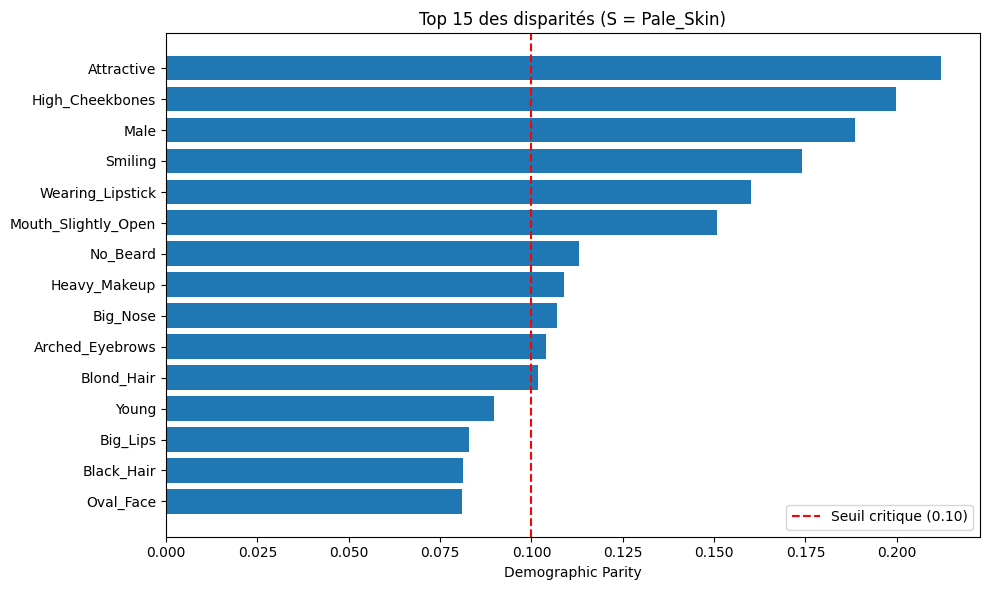

In [17]:
# Collecte des métriques pour tous les attributs vs S=Pale_Skin
fairness_results_pale = []
for attr in attribute_cols:
    if attr != 'Pale_Skin':
        m = compute_fairness_metrics(df_attrs, 'Pale_Skin', attr)
        fairness_results_pale.append((attr, m['Demographic Parity'], m['Disparate Impact']))

fairness_df = pd.DataFrame(fairness_results_pale, columns=['Attribute', 'Demographic Parity', 'Disparate Impact'])
fairness_df = fairness_df.sort_values('Demographic Parity', ascending=False).head(15)

# Visualisation finale
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fairness_df['Attribute'], fairness_df['Demographic Parity'])
ax.axvline(x=0.1, color='red', linestyle='--', label='Seuil critique (0.10)')
ax.set_xlabel('Demographic Parity')
ax.set_title("Top 15 des disparités (S = Pale_Skin)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

**Conclusions sur la fairness** :
- Le biais majeur observé est `Attractive` vs `Pale_Skin`, avec une très forte corrélation (et une large différence de probabilité). Cela peut s'adresser par des techniques variées de traitement ou de re-ponderation des données.
- De manière générale, on observe que certaines variables sont structurellement entrelacées, amplifiant tout biais lors de l'entraînement d'un modèle dessus. Ne jamais utiliser les valeurs subjectives (*Attractive*) sans pré-traitement profond, si possible.

## 2. Apprentissage automatique

- Entraîner un modèle en utilisant les images en entrée et l’attribut Smiling..
Justifier le choix de votre modèle.
- Décrivez et commentez les résultats.
- Évaluation de l’équité: Comparer les performances par sous-groupes
sensibles : (e.g. Accuracy par genre, FPR / FNR par groupe, Écart de
performance entre groupes)

## 3. Explication post-hoc

- Appliquez deux méthodes d’explication post-hoc
- Générer des explications locales pour un cas correct, un cas incorrect et un
cas de groupe minoritaire
- commenter et conclure sur votre modèle.
- Si le modèle n’a pas appris le bon concept, proposer une intervention et
recommencer.